In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/notjustauser/02-features/__results__.html
/kaggle/input/notebooks/notjustauser/02-features/smard_features.parquet
/kaggle/input/notebooks/notjustauser/02-features/feature_engineering_config.json
/kaggle/input/notebooks/notjustauser/02-features/__notebook__.ipynb
/kaggle/input/notebooks/notjustauser/02-features/__output__.json
/kaggle/input/notebooks/notjustauser/02-features/custom.css
/kaggle/input/notebooks/notjustauser/04-lstm/X_scaler.joblib
/kaggle/input/notebooks/notjustauser/04-lstm/y_scaler.joblib
/kaggle/input/notebooks/notjustauser/04-lstm/lstm_horizon_metrics.csv
/kaggle/input/notebooks/notjustauser/04-lstm/lstm_predictions.parquet
/kaggle/input/notebooks/notjustauser/04-lstm/__results__.html
/kaggle/input/notebooks/notjustauser/04-lstm/lstm_metrics.csv
/kaggle/input/notebooks/notjustauser/04-lstm/lstm_config.json
/kaggle/input/notebooks/notjustauser/04-lstm/__notebook__.ipynb
/kaggle/input/notebooks/notjustauser/04-lstm/__output__.json
/kaggle/input/n

In [2]:
import os
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
SEED = 56

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
FEATURE_PATH = "/kaggle/input/notebooks/notjustauser/02-features/smard_features.parquet"

data = pd.read_parquet(FEATURE_PATH)

print(data.shape)
display(data.head())

(17568, 20)


,price_eur_mwh,load_actual_mwh,load_forecast_mwh,hour_sin,hour_cos,dow_sin,dow_cos,weekend,price_lag_1,price_lag_24,price_lag_48,price_lag_168,price_roll_mean_24,price_roll_std_24,price_roll_mean_168,price_roll_std_168,features_valid,forecast_load_available,actual_load_available,model_row_valid
timestamp,,,,,,,,,,,,,,,,,,,,
2022-08-31 19:00:00+00:00,677.26,54065.25,54673.50,-0.707107,0.707107,0.974928,-0.222521,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,True,False
2022-08-31 20:00:00+00:00,563.52,50545.00,50893.75,-0.500000,0.866025,0.974928,-0.222521,0,677.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,True,False
2022-08-31 21:00:00+00:00,532.51,46610.50,47281.75,-0.258819,0.965926,0.974928,-0.222521,0,563.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,True,False
2022-08-31 22:00:00+00:00,490.77,43779.50,45334.25,0.000000,1.000000,0.433884,-0.900969,0,532.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,True,False
2022-08-31 23:00:00+00:00,484.36,42271.75,43953.25,0.258819,0.965926,0.433884,-0.900969,0,490.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,True,False


In [6]:
print(data.dtypes)
print(data.isna().sum())

price_eur_mwh              float64
load_actual_mwh            float64
load_forecast_mwh          float64
hour_sin                   float64
hour_cos                   float64
dow_sin                    float64
dow_cos                    float64
weekend                       int8
price_lag_1                float64
price_lag_24               float64
price_lag_48               float64
price_lag_168              float64
price_roll_mean_24         float64
price_roll_std_24          float64
price_roll_mean_168        float64
price_roll_std_168         float64
features_valid                bool
forecast_load_available       bool
actual_load_available         bool
model_row_valid               bool
dtype: object
price_eur_mwh                0
load_actual_mwh              0
load_forecast_mwh           97
hour_sin                     0
hour_cos                     0
dow_sin                      0
dow_cos                      0
weekend                      0
price_lag_1                  1
price_l

In [7]:
SPLIT_PATH = "/kaggle/input/notebooks/notjustauser/03-baselines/split_config.json"

with open(SPLIT_PATH, "r") as f:
    split_config = json.load(f)

split_config

{'lookback_hours': 168,
 'forecast_horizon_hours': 24,
 'split_method': 'chronological_70_15_15',
 'train_first_target': '2022-09-07 19:00:00+00:00',
 'train_last_target': '2024-01-27 13:00:00+00:00',
 'validation_first_target': '2024-01-27 14:00:00+00:00',
 'validation_last_target': '2024-05-15 04:00:00+00:00',
 'test_first_target': '2024-05-15 05:00:00+00:00',
 'test_last_target': '2024-08-31 19:00:00+00:00'}

In [8]:
X_SCALER_PATH = (
    "/kaggle/input/notebooks/notjustauser/"
    "04-lstm/X_scaler.joblib"
)

Y_SCALER_PATH = (
    "/kaggle/input/notebooks/notjustauser/"
    "04-lstm/y_scaler.joblib"
)

LSTM_CONFIG_PATH = (
    "/kaggle/input/notebooks/notjustauser/"
    "04-lstm/lstm_config.json"
)

CNN_LSTM_MODEL_PATH = (
    "/kaggle/working/models/best_cnn_lstm.keras"
)

X_scaler = joblib.load(X_SCALER_PATH)
y_scaler = joblib.load(Y_SCALER_PATH)

In [9]:
with open(LSTM_CONFIG_PATH, "r") as f:
    lstm_config = json.load(f)

lstm_config

{'model': 'LSTM',
 'lookback': 168,
 'horizon': 24,
 'features_cols': ['load_actual_mwh',
  'load_forecast_mwh',
  'hour_sin',
  'hour_cos',
  'dow_sin',
  'dow_cos',
  'weekend',
  'price_lag_1',
  'price_lag_24',
  'price_lag_48',
  'price_lag_168',
  'price_roll_mean_24',
  'price_roll_std_24',
  'price_roll_mean_168',
  'price_roll_std_168'],
 'lstm_units': 64,
 'dropout': 0.2,
 'dense_units': 64,
 'optimizer': 'Adam',
 'learning_rate': 0.001,
 'loss': 'Huber',
 'batch_size': 64,
 'max_epochs': 125,
 'seed': 56}

In [10]:
LOOKBACK = lstm_config["lookback"]
HORIZON = lstm_config["horizon"]

features_cols = lstm_config["features_cols"]

TARGET_COL = "price_eur_mwh"

In [11]:
print("Lookback:", LOOKBACK)
print("Horizon:", HORIZON)
print("Features:", len(features_cols))

print(features_cols)

Lookback: 168
Horizon: 24
Features: 15
['load_actual_mwh', 'load_forecast_mwh', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'weekend', 'price_lag_1', 'price_lag_24', 'price_lag_48', 'price_lag_168', 'price_roll_mean_24', 'price_roll_std_24', 'price_roll_mean_168', 'price_roll_std_168']


In [12]:
EXPECTED_FEATURES = [
    "load_actual_mwh",
    "load_forecast_mwh",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "weekend",
    "price_lag_1",
    "price_lag_24",
    "price_lag_48",
    "price_lag_168",
    "price_roll_mean_24",
    "price_roll_std_24",
    "price_roll_mean_168",
    "price_roll_std_168",
]

# Frozen model contract
assert LOOKBACK == 168
assert HORIZON == 24
assert features_cols == EXPECTED_FEATURES

required_columns = EXPECTED_FEATURES + [TARGET_COL]
missing_columns = [
    column for column in required_columns
    if column not in data.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

# Timestamp contract
if not isinstance(data.index, pd.DatetimeIndex):
    raise TypeError("Data index must be a DatetimeIndex.")

if data.index.tz is None or str(data.index.tz) != "UTC":
    raise ValueError("Feature data must use a UTC index.")

if not data.index.is_monotonic_increasing:
    raise ValueError("Timestamps must be sorted.")

if not data.index.is_unique:
    raise ValueError("Duplicate timestamps were detected.")

hourly_steps = (
    data.index
    .to_series()
    .diff()
    .dropna()
    .eq(pd.Timedelta(hours=1))
)

if not hourly_steps.all():
    raise ValueError("Feature data is not continuous hourly data.")

# Scaler contract
assert X_scaler.n_features_in_ == len(EXPECTED_FEATURES)
assert y_scaler.n_features_in_ == 1

if hasattr(X_scaler, "feature_names_in_"):
    assert list(X_scaler.feature_names_in_) == EXPECTED_FEATURES

if hasattr(y_scaler, "feature_names_in_"):
    assert list(y_scaler.feature_names_in_) == [TARGET_COL]

print("Frozen preprocessing contract validated.")

Frozen preprocessing contract validated.


In [13]:
X_scaled = np.full(
    (len(data), len(features_cols)),
    np.nan,
    dtype=np.float32
)

In [14]:
valid_feature_rows = (
    data[features_cols]
    .notna()
    .all(axis=1)
)

In [15]:
X_scaled[valid_feature_rows] = (
    X_scaler.transform(
        data.loc[
            valid_feature_rows,
            features_cols
        ]
    )
    .astype(np.float32)
)

In [16]:
y_scaled = (
    y_scaler
    .transform(
        data[[TARGET_COL]]
    )
    .ravel()
    .astype(np.float32)
)

In [17]:
print("X_scaled:", X_scaled.shape)
print("y_scaled:", y_scaled.shape)

X_scaled: (17568, 15)
y_scaled: (17568,)


In [18]:
X_all = []
y_all = []
target_start_times = []

skipped_missing_X = 0

for start in range(
    LOOKBACK,
    len(data) - HORIZON + 1
):

    X_window = X_scaled[
        start - LOOKBACK : start
    ]

    y_window = y_scaled[
        start : start + HORIZON
    ]

    if np.isnan(X_window).any():
        skipped_missing_X += 1
        continue

    if np.isnan(y_window).any():
        continue

    if X_window.shape != (
        LOOKBACK,
        len(features_cols)
    ):
        continue

    if y_window.shape != (HORIZON,):
        continue

    X_all.append(X_window.copy())
    y_all.append(y_window.copy())

    target_start_times.append(
        data.index[start]
    )

In [19]:
X_all = np.stack(X_all).astype(np.float32)
y_all = np.stack(y_all).astype(np.float32)

target_start_times = pd.DatetimeIndex(
    target_start_times
)

In [20]:
print("X:", X_all.shape)
print("y:", y_all.shape)

print(
    "Skipped missing-feature windows:",
    skipped_missing_X
)

X: (16444, 168, 15)
y: (16444, 24)
Skipped missing-feature windows: 933


In [21]:
train_first = pd.Timestamp(
    split_config["train_first_target"]
)

train_last = pd.Timestamp(
    split_config["train_last_target"]
)

val_first = pd.Timestamp(
    split_config["validation_first_target"]
)

val_last = pd.Timestamp(
    split_config["validation_last_target"]
)

test_first = pd.Timestamp(
    split_config["test_first_target"]
)

test_last = pd.Timestamp(
    split_config["test_last_target"]
)

In [22]:
train_mask = (
    (target_start_times >= train_first)
    &
    (target_start_times <= train_last)
)

val_mask = (
    (target_start_times >= val_first)
    &
    (target_start_times <= val_last)
)

test_mask = (
    (target_start_times >= test_first)
    &
    (target_start_times <= test_last)
)

In [23]:
X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_val = X_all[val_mask]
y_val = y_all[val_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]

test_times = target_start_times[test_mask]

In [24]:
print("TRAIN:", X_train.shape, y_train.shape)
print("VAL:", X_val.shape, y_val.shape)
print("TEST:", X_test.shape, y_test.shape)

TRAIN: (11230, 168, 15) (11230, 24)
VAL: (2607, 168, 15) (2607, 24)
TEST: (2607, 168, 15) (2607, 24)


In [25]:
def build_cnn_lstm(
    input_shape,
    horizon=24
):

    inp = keras.Input(
        shape=input_shape
    )

    x = layers.Conv1D(
        filters=32,
        kernel_size=3,
        padding="causal",
        activation="relu"
    )(inp)

    """x = layers.BatchNormalization()(x)"""

    x = layers.MaxPooling1D(
        pool_size=2
    )(x)

    x = layers.Conv1D(
        filters=32,
        kernel_size=3,
        padding="causal",
        activation="relu"
    )(x)

    x = layers.LSTM(
        64,
        dropout=0.2
    )(x)

    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.2
    )(x)

    out = layers.Dense(
        horizon
    )(x)

    model = keras.Model(
        inp,
        out
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),

        loss=keras.losses.Huber(),

        metrics=[
            keras.metrics.MeanAbsoluteError()
        ]
    )

    return model

In [26]:
model = build_cnn_lstm(
    input_shape=(
        X_train.shape[1],
        X_train.shape[2]
    ),
    horizon=HORIZON
)

I0000 00:00:1790584289.598551      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790584289.601379      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [27]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 168, 15)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 168, 32)        │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 84, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 84, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,128 (137.22 KB)

 Trainable params: 35,128 (137.22 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
os.makedirs(
    "/kaggle/working/models",
    exist_ok=True
)

In [29]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5
    ),

    keras.callbacks.ModelCheckpoint(
        "/kaggle/working/models/best_cnn_lstm.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [30]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=125,

    batch_size=64,

    callbacks=callbacks,

    shuffle=False,

    verbose=1
)

Epoch 1/125
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.5106 - mean_absolute_error: 0.8324 - val_loss: 0.1335 - val_mean_absolute_error: 0.3802 - learning_rate: 0.0010
Epoch 2/125
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4058 - mean_absolute_error: 0.7255 - val_loss: 0.1338 - val_mean_absolute_error: 0.3964 - learning_rate: 0.0010
Epoch 3/125
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3659 - mean_absolute_error: 0.6793 - val_loss: 0.1318 - val_mean_absolute_error: 0.3918 - learning_rate: 0.0010
Epoch 4/125
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3377 - mean_absolute_error: 0.6486 - val_loss: 0.1342 - val_mean_absolute_error: 0.3955 - learning_rate: 0.0010
Epoch 5/125
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3119 - mean_absolute_error: 0.6185 - val_loss: 0.1334 - val_mean_absolute_error: 0.3926 - learning_rate: 0.0010
Epoch 6/125
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3058 - mean_absolute_error: 0.6108 - val_loss: 0.1313 - val_m

In [31]:
FROZEN_MODEL_PATH = (
    "/kaggle/working/models/"
    "best_cnn_lstm.keras"
)

frozen_model = keras.models.load_model(
    FROZEN_MODEL_PATH,
    compile=False
)

assert tuple(
    frozen_model.input_shape[1:]
) == (
    LOOKBACK,
    len(features_cols)
)

assert tuple(
    frozen_model.output_shape[1:]
) == (
    HORIZON,
)

probe_prediction = frozen_model.predict(
    X_test[:1],
    verbose=0
)

assert probe_prediction.shape == (1, HORIZON)
assert np.isfinite(probe_prediction).all()

print("Permanent frozen model loaded successfully.")
print("Input:", frozen_model.input_shape)
print("Output:", frozen_model.output_shape)

Permanent frozen model loaded successfully.
Input: (None, 168, 15)
Output: (None, 24)


In [32]:
FROZEN_MODEL_PATH = (
    "/kaggle/working/models/"
    "best_cnn_lstm.keras"
)

# Load the saved best checkpoint.
frozen_model = keras.models.load_model(
    FROZEN_MODEL_PATH,
    compile=False
)

# Validate model structure.
assert tuple(
    frozen_model.input_shape[1:]
) == (
    LOOKBACK,
    len(features_cols)
)

assert tuple(
    frozen_model.output_shape[1:]
) == (
    HORIZON,
)

# Confirm that inference works.
probe_prediction = frozen_model.predict(
    X_test[:1],
    verbose=0
)

assert probe_prediction.shape == (
    1,
    HORIZON
)

assert np.isfinite(
    probe_prediction
).all()

print("Frozen production model validated.")
print("Input shape:", frozen_model.input_shape)
print("Output shape:", frozen_model.output_shape)

Frozen production model validated.
Input shape: (None, 168, 15)
Output shape: (None, 24)


In [33]:
print(history.history["loss"])
print(history.history["val_loss"])

[0.5105786919593811, 0.4057815372943878, 0.36585718393325806, 0.33768999576568604, 0.311862975358963, 0.30579641461372375, 0.2894091308116913, 0.281068354845047, 0.27192190289497375, 0.26371142268180847, 0.24843965470790863, 0.23788303136825562, 0.25032004714012146, 0.2428024411201477, 0.22836971282958984, 0.2363997995853424, 0.21610471606254578, 0.23721683025360107, 0.25011906027793884, 0.2430960088968277, 0.21261374652385712, 0.20114241540431976, 0.19561906158924103, 0.1899586170911789, 0.1859123706817627, 0.17790371179580688, 0.17583930492401123, 0.17417609691619873, 0.17463189363479614, 0.17457585036754608, 0.16983923316001892, 0.16385342180728912, 0.1616271734237671, 0.15865901112556458, 0.15467745065689087, 0.15323834121227264, 0.15014052391052246, 0.1487540602684021, 0.14770567417144775, 0.1468178927898407, 0.1461646854877472, 0.1444436013698578]
[0.1334591507911682, 0.1338455229997635, 0.1318468302488327, 0.1342087686061859, 0.13338801264762878, 0.13131143152713776, 0.127717196

In [34]:
print("Best val epoch:",
      np.argmin(history.history["val_loss"]) + 1)

print("Best val loss:",
      np.min(history.history["val_loss"]))

Best val epoch: 32
Best val loss: 0.07717907428741455


In [35]:
for epoch, (train, val) in enumerate(
    zip(
        history.history["loss"],
        history.history["val_loss"]
    ),
    start=1
):
    print(
        f"Epoch {epoch:2d}: "
        f"train={train:.6f}, "
        f"val={val:.6f}"
    )

Epoch  1: train=0.510579, val=0.133459
Epoch  2: train=0.405782, val=0.133846
Epoch  3: train=0.365857, val=0.131847
Epoch  4: train=0.337690, val=0.134209
Epoch  5: train=0.311863, val=0.133388
Epoch  6: train=0.305796, val=0.131311
Epoch  7: train=0.289409, val=0.127717
Epoch  8: train=0.281068, val=0.120919
Epoch  9: train=0.271922, val=0.122983
Epoch 10: train=0.263711, val=0.119141
Epoch 11: train=0.248440, val=0.113430
Epoch 12: train=0.237883, val=0.110095
Epoch 13: train=0.250320, val=0.104580
Epoch 14: train=0.242802, val=0.108850
Epoch 15: train=0.228370, val=0.110028
Epoch 16: train=0.236400, val=0.108074
Epoch 17: train=0.216105, val=0.106078
Epoch 18: train=0.237217, val=0.105793
Epoch 19: train=0.250119, val=0.091422
Epoch 20: train=0.243096, val=0.089939
Epoch 21: train=0.212614, val=0.087095
Epoch 22: train=0.201142, val=0.085775
Epoch 23: train=0.195619, val=0.084854
Epoch 24: train=0.189959, val=0.085228
Epoch 25: train=0.185912, val=0.087021
Epoch 26: train=0.177904,

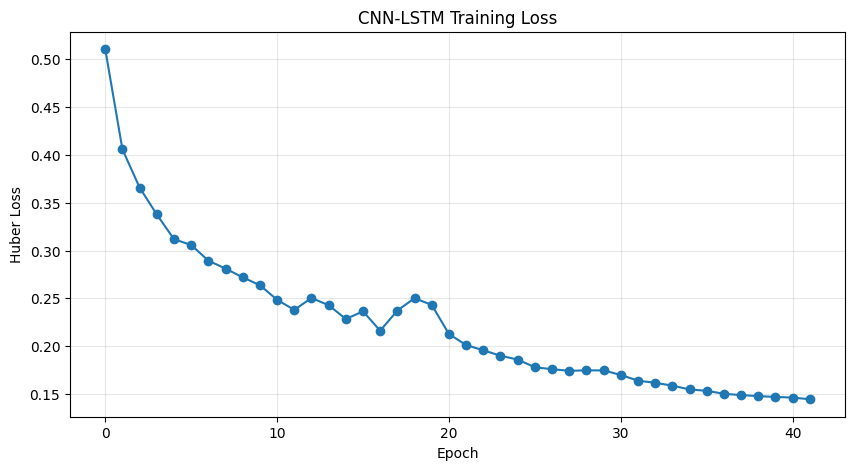

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title("CNN-LSTM Training Loss")
plt.grid(alpha=0.3)
plt.show()

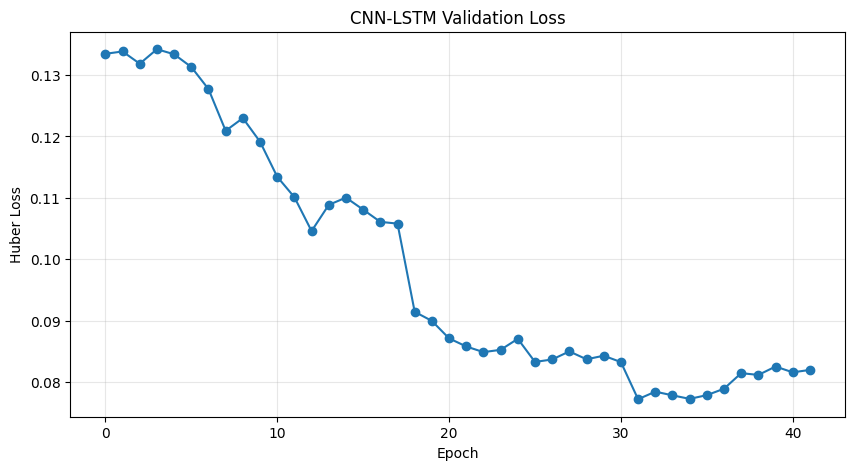

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["val_loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title("CNN-LSTM Validation Loss")
plt.grid(alpha=0.3)
plt.show()

In [38]:
pred_scaled = frozen_model.predict(
    X_test,
    verbose=0
)

In [39]:
print(pred_scaled.shape)

(2607, 24)


In [40]:
pred = (
    y_scaler
    .inverse_transform(
        pred_scaled.reshape(-1, 1)
    )
    .reshape(pred_scaled.shape)
)

In [41]:
actual = (
    y_scaler
    .inverse_transform(
        y_test.reshape(-1, 1)
    )
    .reshape(y_test.shape)
)

In [42]:
print(pred.shape)
print(actual.shape)

(2607, 24)
(2607, 24)


In [43]:
def smape(
    y_true,
    y_pred,
    eps=1e-6
):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return 100 * np.mean(
        2 * np.abs(
            y_pred - y_true
        )
        /
        (
            np.abs(y_true)
            + np.abs(y_pred)
            + eps
        )
    )

In [44]:
actual_flat = actual.ravel()
pred_flat = pred.ravel()

In [45]:
cnn_lstm_mae = mean_absolute_error(
    actual_flat,
    pred_flat
)

In [46]:
cnn_lstm_rmse = np.sqrt(
    mean_squared_error(
        actual_flat,
        pred_flat
    )
)

In [47]:
cnn_lstm_smape = smape(
    actual_flat,
    pred_flat
)

In [48]:
print(
    "CNN-LSTM MAE:",
    cnn_lstm_mae
)

print(
    "CNN-LSTM RMSE:",
    cnn_lstm_rmse
)

print(
    "CNN-LSTM sMAPE:",
    cnn_lstm_smape
)

CNN-LSTM MAE: 21.367294311523438
CNN-LSTM RMSE: 28.671334293266682
CNN-LSTM sMAPE: 46.990887


In [49]:
lstm_metrics = pd.read_csv(
    "/kaggle/input/notebooks/notjustauser/04-lstm/lstm_metrics.csv"
)

In [50]:
cnn_metrics = pd.DataFrame(
    [
        {
            "model": "CNN-LSTM",
            "MAE": cnn_lstm_mae,
            "RMSE": cnn_lstm_rmse,
            "sMAPE": cnn_lstm_smape
        }
    ]
)

In [51]:
comparison = pd.concat(
    [
        lstm_metrics,
        cnn_metrics
    ],
    ignore_index=True
)

display(comparison)

,model,MAE,RMSE,sMAPE
0,LSTM,22.423800,29.913784,46.865643
1,CNN-LSTM,21.367294,28.671334,46.990887


In [52]:
horizon_rows = []

for h in range(HORIZON):

    mae_h = mean_absolute_error(
        actual[:, h],
        pred[:, h]
    )

    horizon_rows.append(
        {
            "horizon": h + 1,
            "cnn_lstm_mae": mae_h
        }
    )

cnn_horizon_metrics = pd.DataFrame(
    horizon_rows
)

display(cnn_horizon_metrics)

,horizon,cnn_lstm_mae
0,1,18.891054
1,2,19.052874
2,3,19.490601
3,4,20.081036
4,5,20.761616
5,6,20.731737
6,7,21.045658
7,8,21.229145
8,9,21.799551
9,10,22.383795


In [53]:
lstm_horizon = pd.read_csv(
    "/kaggle/input/notebooks/notjustauser/04-lstm/lstm_horizon_metrics.csv"
)

In [54]:
horizon_comparison = (
    lstm_horizon
    .merge(
        cnn_horizon_metrics,
        on="horizon"
    )
)

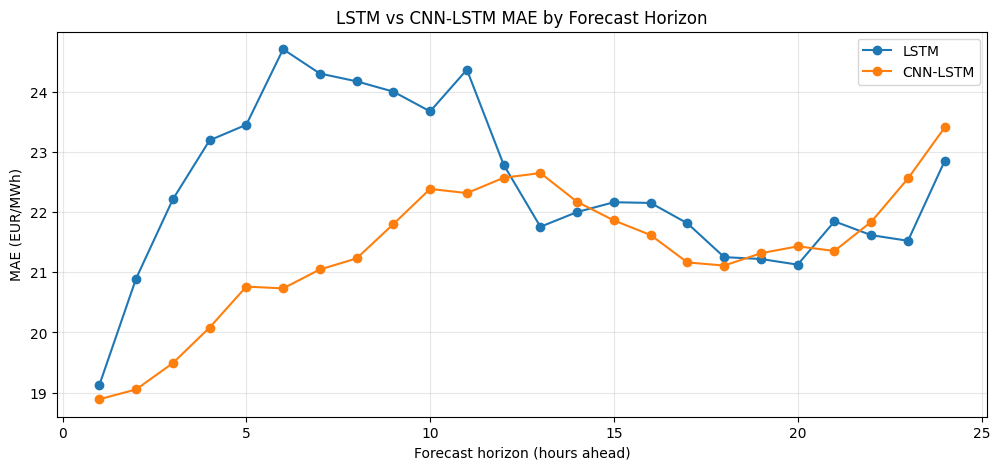

In [55]:
plt.figure(figsize=(12, 5))

plt.plot(
    horizon_comparison["horizon"],
    horizon_comparison["lstm_mae"],
    marker="o",
    label="LSTM"
)

plt.plot(
    horizon_comparison["horizon"],
    horizon_comparison["cnn_lstm_mae"],
    marker="o",
    label="CNN-LSTM"
)

plt.xlabel("Forecast horizon (hours ahead)")
plt.ylabel("MAE (EUR/MWh)")

plt.title(
    "LSTM vs CNN-LSTM MAE by Forecast Horizon"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

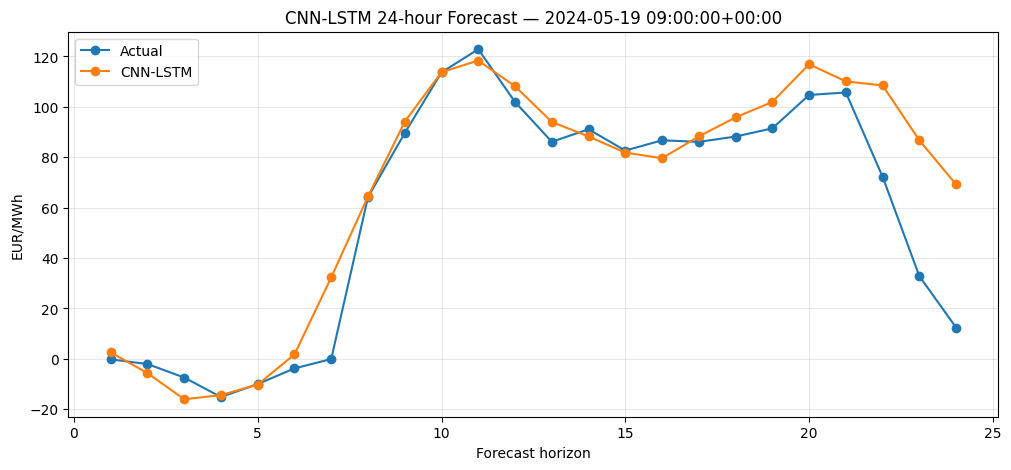

In [56]:
example = 100

hours = np.arange(1, 25)

plt.figure(figsize=(12, 5))

plt.plot(
    hours,
    actual[example],
    marker="o",
    label="Actual"
)

plt.plot(
    hours,
    pred[example],
    marker="o",
    label="CNN-LSTM"
)

plt.xlabel("Forecast horizon")
plt.ylabel("EUR/MWh")

plt.title(
    f"CNN-LSTM 24-hour Forecast — "
    f"{test_times[example]}"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [57]:
threshold = np.quantile(
    np.abs(actual_flat),
    0.95
)

extreme_mask = (
    np.abs(actual_flat)
    >= threshold
)

In [58]:
cnn_extreme_mae = (
    mean_absolute_error(
        actual_flat[extreme_mask],
        pred_flat[extreme_mask]
    )
)

print(
    "Extreme threshold:",
    threshold
)

print(
    "CNN-LSTM extreme MAE:",
    cnn_extreme_mae
)

Extreme threshold: 139.0
CNN-LSTM extreme MAE: 48.111785888671875


In [59]:
negative_mask = (
    actual_flat < 0
)

print(
    "Negative-price observations:",
    negative_mask.sum()
)

Negative-price observations: 6171


In [60]:
if negative_mask.sum() > 0:

    cnn_negative_mae = (
        mean_absolute_error(
            actual_flat[negative_mask],
            pred_flat[negative_mask]
        )
    )

    print(
        "CNN-LSTM negative-price MAE:",
        cnn_negative_mae
    )

CNN-LSTM negative-price MAE: 37.297935485839844


In [61]:
records = []

for i in range(len(actual)):

    for h in range(HORIZON):

        records.append(
            {
                "forecast_start":
                    test_times[i],

                "horizon":
                    h + 1,

                "actual":
                    actual[i, h],

                "cnn_lstm":
                    pred[i, h]
            }
        )

In [62]:
cnn_predictions = pd.DataFrame(
    records
)

In [63]:
cnn_predictions.to_parquet(
    "/kaggle/working/cnn_lstm_predictions.parquet",
    index=False
)

In [64]:
cnn_metrics.to_csv(
    "/kaggle/working/cnn_lstm_metrics.csv",
    index=False
)

In [65]:
cnn_horizon_metrics.to_csv(
    "/kaggle/working/cnn_lstm_horizon_metrics.csv",
    index=False
)

In [66]:
comparison.to_csv(
    "/kaggle/working/lstm_vs_cnn_lstm.csv",
    index=False
)

In [67]:
conv_layers = [
    layer for layer in frozen_model.layers
    if isinstance(layer, layers.Conv1D)
]

lstm_layers = [
    layer for layer in frozen_model.layers
    if isinstance(layer, layers.LSTM)
]

if len(conv_layers) != 2:
    raise ValueError(
        f"Expected 2 Conv1D layers, found {len(conv_layers)}"
    )

if len(lstm_layers) != 1:
    raise ValueError(
        f"Expected 1 LSTM layer, found {len(lstm_layers)}"
    )

cnn_config = {
    "contract_version": 1,
    "model_version": "cnn_lstm_v1_frozen",
    "model": "CNN-LSTM",
    "model_format": "keras",

    "lookback": LOOKBACK,
    "horizon": HORIZON,
    "input_shape": [
        LOOKBACK,
        len(features_cols)
    ],
    "output_shape": [HORIZON],

    "target_col": TARGET_COL,
    "features_cols": features_cols,

    # Read directly from the saved model to prevent mismatches.
    "conv1_filters": int(conv_layers[0].filters),
    "conv1_kernel": int(conv_layers[0].kernel_size[0]),

    "pool_size": 2,

    "conv2_filters": int(conv_layers[1].filters),
    "conv2_kernel": int(conv_layers[1].kernel_size[0]),

    "padding": conv_layers[0].padding,

    "lstm_units": int(lstm_layers[0].units),
    "lstm_dropout": float(lstm_layers[0].dropout),

    "dense_units": 64,
    "dense_dropout": 0.2,

    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "loss": "Huber",

    "batch_size": 64,
    "max_epochs": 125,
    "seed": SEED,

    # Operational contract
    "canonical_timezone": "UTC",
    "display_timezone": "Europe/Berlin",
    "input_frequency": "1h",
    "scheduled_forecast_hour_utc": 12,

    # Notebook 2 needs 168 warm-up hours to produce
    # 168 complete engineered model-input rows.
    "minimum_raw_history_hours": 336,
    "engineered_input_hours": 168,

    "missing_input_policy": "reject_forecast",
    "retraining_policy": "frozen_no_daily_fit",

    "training_first_origin_utc":
        split_config["train_first_target"],

    "training_last_origin_utc":
        split_config["train_last_target"],

    "offline_test_first_origin_utc":
        split_config["test_first_target"],

    "offline_test_last_origin_utc":
        split_config["test_last_target"],
}

In [68]:
with open(
    "/kaggle/working/cnn_lstm_config.json",
    "w"
) as f:

    json.dump(
        cnn_config,
        f,
        indent=4
    )

In [69]:
from pathlib import Path
import hashlib
import shutil
import sklearn

BUNDLE_DIR = Path(
    "/kaggle/working/cnn_lstm_production_bundle"
)

BUNDLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CONFIG_PATH = Path(
    "/kaggle/working/cnn_lstm_config.json"
)

artifact_sources = {
    "best_cnn_lstm.keras":
        Path(CNN_LSTM_MODEL_PATH),

    "X_scaler.joblib":
        Path(X_SCALER_PATH),

    "y_scaler.joblib":
        Path(Y_SCALER_PATH),

    "cnn_lstm_config.json":
        CONFIG_PATH,
}

for output_name, source_path in artifact_sources.items():

    if not source_path.exists():
        raise FileNotFoundError(source_path)

    shutil.copy2(
        source_path,
        BUNDLE_DIR / output_name
    )

# Portable scaler values can be used by a Node/Vercel backend
# without fitting or modifying either scaler.
portable_scalers = {
    "feature_order": features_cols,

    "x_scaler": {
        "type": "StandardScaler",
        "mean": X_scaler.mean_.tolist(),
        "scale": X_scaler.scale_.tolist(),
    },

    "y_scaler": {
        "type": "RobustScaler",
        "center": y_scaler.center_.tolist(),
        "scale": y_scaler.scale_.tolist(),
    },
}

with open(
    BUNDLE_DIR / "scaler_parameters.json",
    "w"
) as f:
    json.dump(
        portable_scalers,
        f,
        indent=4
    )

# Full preprocessing + prediction smoke-test fixture.
probe_origin = test_times[0]
probe_position = data.index.get_loc(probe_origin)

probe_frame = data.iloc[
    probe_position - LOOKBACK : probe_position
][features_cols]

if probe_frame.shape != (
    LOOKBACK,
    len(features_cols)
):
    raise ValueError("Invalid smoke-test input shape.")

if probe_frame.isna().any().any():
    raise ValueError("Smoke-test input contains missing values.")

probe_scaled = (
    X_scaler
    .transform(probe_frame)
    .astype(np.float32)
)

np.testing.assert_allclose(
    probe_scaled,
    X_test[0],
    rtol=1e-5,
    atol=1e-5
)

probe_prediction_scaled = frozen_model.predict(
    probe_scaled[None, :, :],
    verbose=0
)

probe_prediction = (
    y_scaler
    .inverse_transform(
        probe_prediction_scaled.reshape(-1, 1)
    )
    .ravel()
)

smoke_test = {
    "forecast_origin_utc":
        probe_origin.isoformat(),

    "feature_order":
        features_cols,

    "raw_input":
        probe_frame.astype(float).values.tolist(),

    "expected_prediction_eur_mwh":
        probe_prediction.astype(float).tolist(),
}

with open(
    BUNDLE_DIR / "smoke_test.json",
    "w"
) as f:
    json.dump(
        smoke_test,
        f
    )

def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b""
        ):
            digest.update(block)

    return digest.hexdigest()

artifact_hashes = {}

for path in sorted(BUNDLE_DIR.rglob("*")):
    if path.is_file():
        relative_path = str(
            path.relative_to(BUNDLE_DIR)
        )

        artifact_hashes[relative_path] = (
            sha256_file(path)
        )

production_manifest = {
    "model_version": "cnn_lstm_v1_frozen",
    "tensorflow_version": tf.__version__,
    "sklearn_version": sklearn.__version__,
    "input_shape": [1, 168, 15],
    "output_shape": [1, 24],
    "feature_order": features_cols,
    "artifacts_sha256": artifact_hashes,
}

with open(
    BUNDLE_DIR / "production_manifest.json",
    "w"
) as f:
    json.dump(
        production_manifest,
        f,
        indent=4
    )

print("Production bundle:", BUNDLE_DIR)
print("Artifacts:", sorted(artifact_hashes))

Production bundle: /kaggle/working/cnn_lstm_production_bundle
Artifacts: ['X_scaler.joblib', 'best_cnn_lstm.keras', 'cnn_lstm_config.json', 'scaler_parameters.json', 'smoke_test.json', 'y_scaler.joblib']


In [70]:
from pathlib import Path
import shutil
import joblib
import hashlib
import json

PRODUCTION_DIR = Path(
    "/kaggle/working/production_model"
)

PRODUCTION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Copy the exact saved model.
shutil.copy2(
    FROZEN_MODEL_PATH,
    PRODUCTION_DIR / "best_cnn_lstm.keras"
)

# Save the exact scalers used during training.
joblib.dump(
    X_scaler,
    PRODUCTION_DIR / "X_scaler.joblib"
)

joblib.dump(
    y_scaler,
    PRODUCTION_DIR / "y_scaler.joblib"
)

# Copy the corrected configuration.
shutil.copy2(
    "/kaggle/working/cnn_lstm_config.json",
    PRODUCTION_DIR / "cnn_lstm_config.json"
)

def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b""
        ):
            digest.update(block)

    return digest.hexdigest()

manifest = {
    "model_name": "CNN-LSTM",
    "status": "production_frozen",
    "lookback_hours": 168,
    "forecast_horizon_hours": 24,
    "input_features": features_cols,
    "input_shape": [1, 168, 15],
    "output_shape": [1, 24],
    "automatic_retraining": False,
    "files": {}
}

for path in PRODUCTION_DIR.iterdir():
    if path.is_file():
        manifest["files"][path.name] = {
            "sha256": sha256_file(path)
        }

with open(
    PRODUCTION_DIR / "production_manifest.json",
    "w"
) as file:
    json.dump(
        manifest,
        file,
        indent=2
    )

# Create a downloadable backup.
shutil.make_archive(
    "/kaggle/working/"
    "cnn_lstm_production_model",
    "zip",
    PRODUCTION_DIR
)

print("Permanent production bundle created:")
print(
    "/kaggle/working/"
    "cnn_lstm_production_model.zip"
)

Permanent production bundle created:
/kaggle/working/cnn_lstm_production_model.zip
